We build on a sentiment signal `ev` drawn from `{positiveP, negativeP, BULL, BEAR, BBr, PNlog}` together with the news-volume series `RVT`. The strategy runs long-only and long-short, tuned, evaluated on rolling windows of length 254 and 127, and reported with a 1% cost per trade. We report every configuration whose excess return over buy-and-hold is positive (Me minus BH greater than 0), along with the full Lab 6 metric set and the trade count. The extra credit is to carry the transaction cost into the rolling-window test.

This notebook designs two strategies that are both different from MAcross and RSI, and presents them as co-equal answers:

1. A single-stock sentiment z-score band. We standardise an `ev` series over a rolling window, then take a position when the signal moves more than `k` standard deviations away from its own recent mean. This is the most literal fit to Q1, because it is tested against single-stock buy-and-hold, exactly the Me minus BH the assignment asks for.
2. A relative-sentiment pairs trade between JPM and HSBC. We trade the gap between the two banks' sentiment, long one bank and short the other. This is the flagship idea from the project plan. It is dollar-neutral by construction (equal size on each leg) and benchmarked against the equal-weight long-both portfolio from L7.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

SEED = 42
np.random.seed(SEED)
COST = 0.01                                
COVID_CUT = pd.Timestamp("2020-02-20")    

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## 1. Data and sentiment indicators

We load each stock, keep the adjusted close as the price target, and build the sentiment series from the part-of-speech sentiment scores in the file. The four constructed series follow the Lab 6 definitions:

- `BULL = 0.33 * (positiveP + certaintyP + finupP)`
- `BEAR = 0.33 * (negativeP + uncertaintyP + findownP)`
- `BBr  = 100 * BULL / (BULL + BEAR)`, a bull share between 0 and 100
- `PNlog = 0.5 * log((positiveP + 1) / (negativeP + 1))`, a log polarity score

We also keep `RVT`, the relative news volume, which we use later as a regime filter. Any gaps in the sentiment series are filled by linear interpolation, then forward and backward fill at the ends, so the position rules never see a missing value.

In [2]:
def load_stock(path):
    df = pd.read_csv(path)
    df = df.drop(columns=df.columns[0])          # drop the unnamed integer index column
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").astype(float)
    return df

def build_ev(df):
    # Adjusted close target, RVT, and the six sentiment series from Lab 6.
    positiveP = df["positivePartscr"]
    negativeP = df["negativePartscr"]
    certaintyP = df["certaintyPartscr"]
    uncertaintyP = df["uncertaintyPartscr"]
    finupP = df["finupPartscr"]
    findownP = df["findownPartscr"]

    BULL = 0.33 * (positiveP + certaintyP + finupP)
    BEAR = 0.33 * (negativeP + uncertaintyP + findownP)

    BB = BULL + BEAR
    BB = BB.mask(BB == 0, np.nan)
    BBr = 100 * BULL / BB
    BBr = BBr.ffill().bfill()

    PNlog = 0.5 * np.log((positiveP + 1) / (negativeP + 1))

    out = pd.DataFrame({
        "target": df["Adj Close"],
        "RVT": df["RVT"],
        "positiveP": positiveP,
        "negativeP": negativeP,
        "BULL": BULL,
        "BEAR": BEAR,
        "BBr": BBr,
        "PNlog": PNlog,
    })
    return out.interpolate().ffill().bfill()

In [3]:
hsbc = build_ev(load_stock("HSBC.csv"))
jpm = build_ev(load_stock("JPM.csv"))

common = hsbc.index.intersection(jpm.index)
hsbc, jpm = hsbc.loc[common], jpm.loc[common]

r_h = (hsbc.target / hsbc.target.shift(1) - 1)        # HSBC daily simple return
r_j = (jpm.target / jpm.target.shift(1) - 1)          # JPM daily simple return

print("rows:", len(common), "| range:", common.min().date(), "->", common.max().date())
print("identical date index:", hsbc.index.equals(jpm.index))
print("any NaN left, HSBC:", bool(hsbc.isna().any().any()), "| JPM:", bool(jpm.isna().any().any()))
hsbc.head()

rows: 602 | range: 2018-01-02 -> 2020-05-22
identical date index: True
any NaN left, HSBC: False | JPM: False


,target,RVT,positiveP,negativeP,BULL,BEAR,BBr,PNlog
Date,,,,,,,,
2018-01-02,45.216980,0.0011,0.0110,0.0113,0.014058,0.008811,61.471861,-0.000148
2018-01-03,44.992668,0.0008,0.0024,0.0030,0.002409,0.003399,41.477273,-0.000299
2018-01-04,45.087566,0.0010,0.0035,0.0055,0.002739,0.004785,36.403509,-0.000996
2018-01-05,45.009918,0.0010,0.0089,0.0246,0.010329,0.013299,43.715084,-0.007721
2018-01-08,44.647560,0.0011,0.0045,0.0055,0.003366,0.005676,37.226277,-0.000498




**Note:** the sample ends in May 2020, so the COVID crash of February and March 2020 sits inside the data. The crash is the most violent part of the sample and it lands inside the test window once we split the data for tuning. Keep this in mind: a strategy can look good or bad mostly because of how it happened to be positioned during those few weeks. Section 10 splits the result into pre-COVID and COVID pieces so you can see how much of the edge comes from the crash.

The plots below show the two price series, the daily returns in percent, the `BBr` bull share, and the `RVT` news volume. Notice how `RVT` spikes during the COVID weeks. That spike is what the regime filter is built to catch.

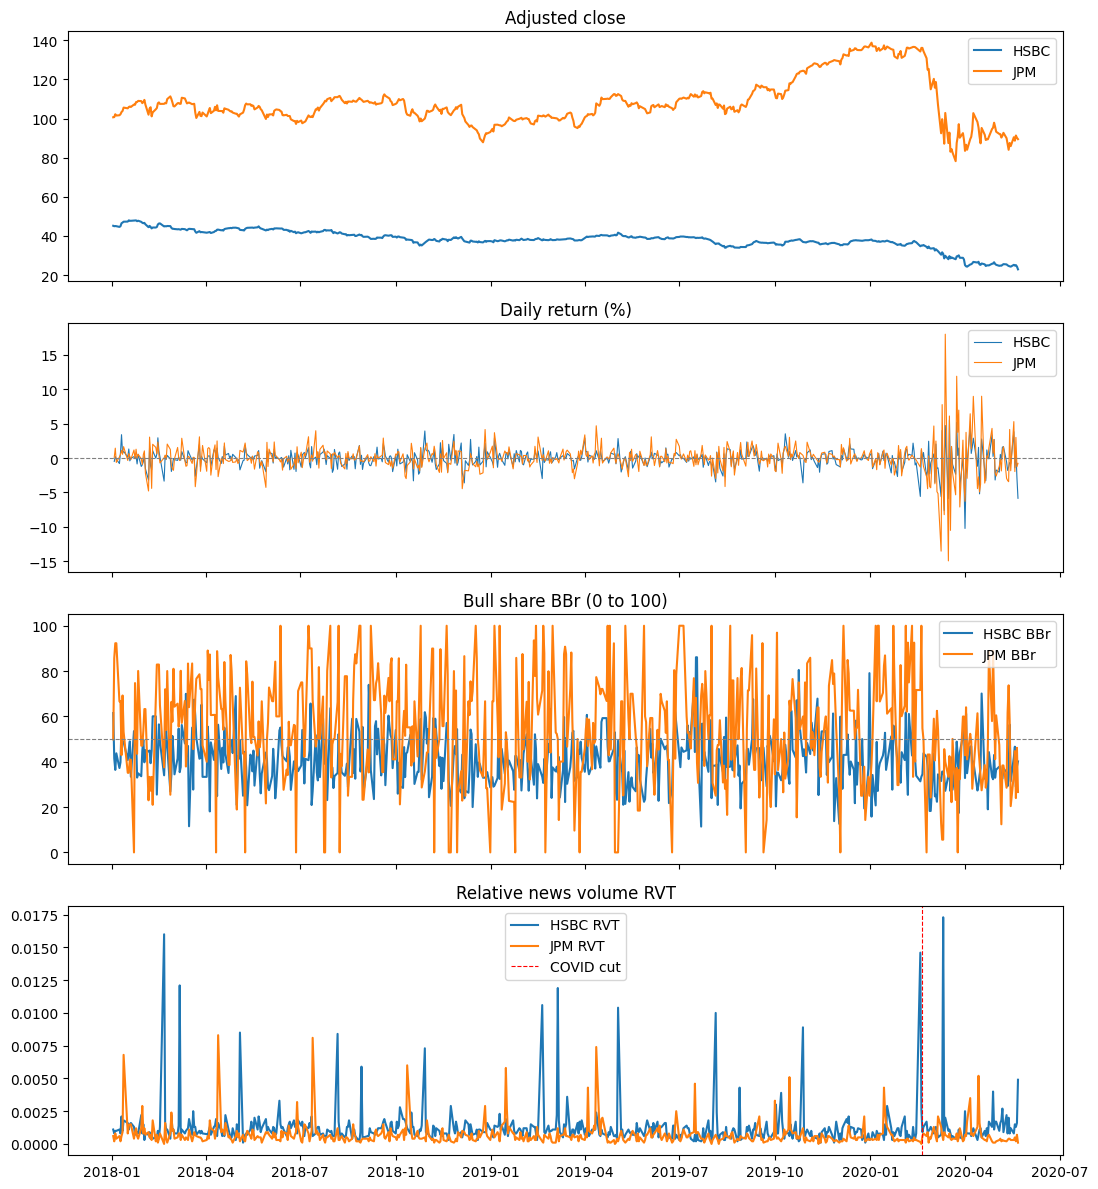

In [4]:
fig, ax = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
ax[0].plot(hsbc.index, hsbc.target, label="HSBC")
ax[0].plot(jpm.index, jpm.target, label="JPM")
ax[0].set_title("Adjusted close")
ax[0].legend()
ax[1].plot(hsbc.index, r_h * 100, label="HSBC", lw=0.8)
ax[1].plot(jpm.index, r_j * 100, label="JPM", lw=0.8)
ax[1].axhline(0, color="grey", lw=0.8, ls="--")
ax[1].set_title("Daily return (%)")
ax[1].legend()
ax[2].plot(hsbc.index, hsbc.BBr, label="HSBC BBr")
ax[2].plot(jpm.index, jpm.BBr, label="JPM BBr")
ax[2].axhline(50, color="grey", lw=0.8, ls="--")
ax[2].set_title("Bull share BBr (0 to 100)")
ax[2].legend()
ax[3].plot(hsbc.index, hsbc.RVT, label="HSBC RVT")
ax[3].plot(jpm.index, jpm.RVT, label="JPM RVT")
ax[3].axvline(COVID_CUT, color="red", lw=0.8, ls="--", label="COVID cut")
ax[3].set_title("Relative news volume RVT")
ax[3].legend()
plt.tight_layout()
plt.show()

**Note:** the daily-return panel makes the volatility clustering plain. The swings are small and steady through 2018 and 2019, then blow out in February and March 2020. This matters twice over. It is the percent return series that every strategy below actually trades, so the COVID weeks are where most of the cumulative profit and loss is made or lost. It is also why the Lab 6 cumulative-return convention, which adds simple returns rather than compounding them, can read oddly during the crash. The harness note in Section 2 covers that.

## 2. Performance harness

This is the Lab 6 scoring code. `performance` turns a series of strategy returns into the eight metrics the lab reports:

- Cumulative Return, computed additively as the running sum of daily returns minus a lump transaction cost of `n.trades * cost`
- Annual Return, the cumulative figure annualised over 252 trading days
- Annualised Sharpe Ratio
- Win %, the share of non-zero days that are positive
- Annualised Volatility
- Maximum Drawdown and its length, using the lab's own drawdown definition
- n.trades, the number of trades

`count_trades` counts sign changes in the position and adds one. We drop missing values before counting so that the leading `NaN` from the one-day signal shift does not inflate the count, which is a small but important fix relative to the raw lab code.

In [ ]:
PERF_NAMES = ["Cumulative Return", "Annual Return", "Annualized Sharpe Ratio",
              "Win %", "Annualized Volatility", "Maximum Drawdown",
              "Max Length Drawdown", "n.trades"]

def performance(x, ntrades=1, cost=0.0):
    name = getattr(x, "name", None)
    xv = np.asarray(x, dtype=float)
    with np.errstate(all="ignore"):                 
        cumRetx = np.cumsum(xv) - ntrades * cost
        annRetx = np.power(cumRetx[-1] + 1, 252 / len(xv)) - 1
        sharpex = annRetx / np.std(xv, ddof=1) * np.sqrt(252)
        winpctx = np.count_nonzero(xv > 0) / np.count_nonzero(xv)
        annSDx = np.std(xv, ddof=1) * np.sqrt(252)
        DDs = np.minimum.accumulate(cumRetx) - cumRetx
        maxDDx = DDs.min()
        maxLx = (cumRetx == DDs).argmax()
    Perf = np.array([cumRetx[-1], annRetx, sharpex, winpctx, annSDx, maxDDx, maxLx, ntrades])
    return pd.Series(Perf, index=PERF_NAMES, name=name)

def count_trades(sig):
    # sign changes in the shifted position, plus one, with leading NaN dropped first
    s = pd.Series(sig).dropna().to_numpy()
    if len(s) <= 1:
        return 1
    return int(np.count_nonzero(np.diff(s))) + 1

## 3. MAcross baseline

We don't submit MAcross, but it is the natural reference point because it is the Lab 6 strategy we have to improve on in spirit. We run a moving-average crossover on the `BEAR` sentiment series, long-short, with the 1% cost, so we can see what a high-turnover sentiment rule does once cost is charged. The same cell defines `test_strategy` (the full-period scorer) and `rolling_test` (the rolling-window scorer used later).

In [ ]:
def macross_signal(ts, s=5, m=20, longshort=0):
    sig = pd.Series(np.where(ts.rolling(s).mean() > ts.rolling(m).mean(), 1, longshort),
                    index=ts.index).shift(1)
    return sig

def test_strategy(target, sig, cost=COST, leg_mult=1):
    bh = (target / target.shift(1) - 1).rename("BH")
    me = (bh * sig).rename("Me")
    tt = pd.concat([bh, me], axis=1).dropna()
    nt = count_trades(sig) * leg_mult
    me_perf = performance(tt.Me, nt, cost)
    bh_perf = performance(tt.BH, 2, cost)
    res = pd.concat([me_perf, bh_perf], axis=1)
    res.columns = ["Me", "BH"]
    excess = res.loc["Cumulative Return", "Me"] - res.loc["Cumulative Return", "BH"]
    return res, excess

def rolling_test(target, sig, w_size=254, cost=COST, leg_mult=1, apply_cost=True):
    bh = (target / target.shift(1) - 1).rename("BH")
    me = (bh * sig).rename("Me")
    tt = pd.concat([bh, me], axis=1).dropna()
    n_windows = int(tt.shape[0] - w_size)
    if n_windows < 1:
        raise ValueError("Window size too large for available data")
    rows = []
    sig_al = sig.reindex(tt.index)
    for i in range(n_windows):
        bh_w = tt.iloc[i:w_size + i, 0]
        me_w = tt.iloc[i:w_size + i, 1]
        bh_mean = bh_w.mean()
        me_mean = me_w.mean()
        if apply_cost:
            nt_w = count_trades(sig_al.iloc[i:w_size + i]) * leg_mult
            me_mean = me_mean - nt_w * cost / w_size      
        rows.append([bh_mean, me_mean])
    arr = np.array(rows)
    return pd.DataFrame({"AvgPerf": [arr[:, 0].mean(), arr[:, 1].mean()]},
                        index=["BH", "Me"]), n_windows

In [7]:
print("MAcross on BEAR, long-short, full period, cost = 0.01")
for nm, d in [("HSBC", hsbc), ("JPM", jpm)]:
    sig = macross_signal(d.BEAR, s=10, m=25, longshort=-1)
    res, exc = test_strategy(d.target, sig)
    print(f"  {nm}: Me-BH = {exc:+.4f}, n.trades = {int(res.loc['n.trades','Me'])}")

MAcross on BEAR, long-short, full period, cost = 0.01
  HSBC: Me-BH = +0.0916, n.trades = 80
  JPM: Me-BH = -0.9170, n.trades = 79


**Note:** the crossover trades about 80 times over the sample. On HSBC it just clears buy-and-hold, and on JPM it loses heavily once the 1% cost is charged on every one of those trades. This sets up the rest of the notebook: with a 1% cost, turnover is the enemy. Any strategy we design has to keep the trade count low, which is why the designs below hold a position until the signal clearly flips rather than reacting to every small move.

## 4. Strategy design

### 4.1 Single-stock sentiment z-score band

We standardise an `ev` series with a rolling mean and standard deviation over `n` days to get a z-score. When the z-score rises above `+k` we read the news as strongly positive; when it falls below `-k` we read it as strongly negative. In momentum mode we go long on strong-positive and either flat (long-only) or short (long-short) on strong-negative. In contrarian mode we do the opposite, which fades sentiment extremes. Between the bands we hold whatever position we last took, so the rule is stateful and does not churn.

This is different from MAcross, which compares two moving averages of price, and from RSI, which is a bounded oscillator with fixed 30 and 70 levels. Here the levels are adaptive: they move with the recent mean and spread of the sentiment series itself.

### 4.2 RVT regime filter

`RVT` measures how much news is flowing. Lab 6 notes that sentiment behaves differently in quiet periods than in news storms. We turn this into a filter: we smooth `RVT`, compare it to its own expanding (backward-looking) high quantile, and when smoothed news volume is in its top tail we treat it as a high-news regime and stand aside (flat). The filter is deliberately persistent. It uses a smoothed series and a high quantile so that it switches on for contiguous stretches such as the COVID news storm, instead of toggling on and off day to day. An earlier day-by-day version of this filter multiplied the trade count and destroyed returns once cost was charged, so the persistence is not cosmetic, it is what keeps the filter from adding turnover.

### 4.3 Relative-sentiment pairs trade

The pairs trade looks at the gap between JPM and HSBC sentiment, `gap = ev_JPM - ev_HSBC`, standardises it the same way, and trades the spread: when JPM sentiment is far above HSBC we go long JPM and short HSBC, and the other way round when it is far below. The benchmark is the equal-weight long-both portfolio from L7, which is the natural passive alternative to an active spread. This is a genuinely different construction from both MAcross and RSI because the signal is a cross-sectional comparison between two assets, not a function of a single price path.

The pairs trade is long-short by nature. Its long-only variant holds only the leg the signal points to and stays in cash otherwise, so read its long-only row as "one leg at a time" rather than a true flat-or-long rule.

In [ ]:
def rvt_high_regime(rvt, window=20, q=0.90):
    # persistent high-news regime: smoothed RVT above its own backward-looking quantile
    smooth = rvt.rolling(window, min_periods=window).mean()
    thresh = smooth.expanding(min_periods=window).quantile(q)
    return (smooth > thresh).fillna(False)

def zscore_band_signal(ev, n=20, k=1.0, mode="momentum", longshort=0,
                       rvt=None, rvt_window=20, rvt_q=None):
    mu = ev.rolling(n, min_periods=n).mean()
    sd = ev.rolling(n, min_periods=n).std()
    z = (ev - mu) / sd
    raw = pd.Series(np.nan, index=ev.index)
    if mode == "momentum":
        raw = raw.mask(z > k, 1.0)
        raw = raw.mask(z < -k, float(longshort))
    else:                                       
        raw = raw.mask(z < -k, 1.0)
        raw = raw.mask(z > k, float(longshort))
    pos = raw.ffill().fillna(0.0)
    if rvt is not None and rvt_q is not None:
        pos = pos.mask(rvt_high_regime(rvt, rvt_window, rvt_q), 0.0)
    return pos.shift(1)                              # trade the day after the signal is known

def equity_curves(target, sig, cost=COST, leg_mult=1):
    # cumulative Me and BH on the same additive, cost-subtracted basis as performance()
    bh = (target / target.shift(1) - 1).rename("BH")
    me = (bh * sig).rename("Me")
    tt = pd.concat([bh, me], axis=1).dropna()
    nt = count_trades(sig) * leg_mult
    cum_me = tt.Me.cumsum() - nt * cost
    cum_bh = tt.BH.cumsum() - 2 * cost
    return tt.index, cum_me, cum_bh

## 5. Pairs signal and scorer

`pairs_zscore_signal` builds the spread position from the JPM minus HSBC sentiment gap, and `test_pairs` scores the spread against the equal-weight benchmark. Every signal is shifted by one day with `.shift(1)` so that a position is only taken the day after the signal is known. This is the standard guard against look-ahead bias: we never trade on information from the same day's close that produced the signal.

In [9]:
def pairs_zscore_signal(ev_a, ev_b, n=20, k=1.0, mode="momentum",
                        rvt_comb=None, rvt_window=20, rvt_q=None):
    gap = (ev_a - ev_b)
    mu = gap.rolling(n, min_periods=n).mean()
    sd = gap.rolling(n, min_periods=n).std()
    z = (gap - mu) / sd
    raw = pd.Series(np.nan, index=gap.index)
    if mode == "momentum":
        raw = raw.mask(z > k, 1.0)                   # JPM sentiment rich vs HSBC: long JPM, short HSBC
        raw = raw.mask(z < -k, -1.0)
    else:
        raw = raw.mask(z > k, -1.0)
        raw = raw.mask(z < -k, 1.0)
    pos = raw.ffill().fillna(0.0)
    if rvt_comb is not None and rvt_q is not None:
        pos = pos.mask(rvt_high_regime(rvt_comb, rvt_window, rvt_q), 0.0)
    return pos.shift(1)

def pairs_returns(r_a, r_b, sig, longshort=True):
    if longshort:
        return (sig * (r_a - r_b)).rename("Me")
    long_a = (sig == 1).astype(float) * r_a
    long_b = (sig == -1).astype(float) * r_b
    return (long_a + long_b).rename("Me")

def test_pairs(r_a, r_b, sig, longshort=True, cost=COST):
    bh = (0.5 * r_a + 0.5 * r_b).rename("BH")        # equal-weight long-both benchmark, from L7
    me = pairs_returns(r_a, r_b, sig, longshort)
    tt = pd.concat([bh, me], axis=1).dropna()
    leg_mult = 2                                     # two legs traded per rebalance
    nt = count_trades(sig) * leg_mult
    me_perf = performance(tt.Me, nt, cost)
    bh_perf = performance(tt.BH, 2, cost)
    res = pd.concat([me_perf, bh_perf], axis=1)
    res.columns = ["Me", "BH"]
    excess = res.loc["Cumulative Return", "Me"] - res.loc["Cumulative Return", "BH"]
    return res, excess

def pairs_equity_curves(r_a, r_b, sig, longshort=True, cost=COST):
    # cumulative Me (spread) and BH (equal-weight) on the additive, cost-subtracted basis
    bh = (0.5 * r_a + 0.5 * r_b).rename("BH")
    me = pairs_returns(r_a, r_b, sig, longshort).rename("Me")
    tt = pd.concat([bh, me], axis=1).dropna()
    nt = count_trades(sig) * 2
    cum_me = tt.Me.cumsum() - nt * cost
    cum_bh = tt.BH.cumsum() - 2 * cost
    return tt.index, cum_me, cum_bh

## 6. Tuning without look-ahead

We split the sample chronologically at 70%, tune only on the earlier part, and then report on the full sample and on the held-out later part. The split date falls in September 2019, so the held-out part contains the COVID crash. A configuration that is positive on both the training part and the held-out part is far more believable than one that only looks good over the full sample.

The search grid is small: window `n` in {10, 20, 40, 60, 80}, threshold `k` in {0.5, 1.0, 1.5, 2.0, 2.5}, and the RVT quantile in {off, 0.85, 0.90}. The objective is the excess return over buy-and-hold on the training slice. Because the grid is small enough to score exhaustively, the grid search returns the true best point. We also include a short simulated annealing run, the search method from L7, to show the technique and to confirm it lands on a comparable configuration. On a grid this size, simulated annealing is not needed to find the optimum, so we use the exhaustive grid as the workhorse and treat annealing as a demonstration.

In [10]:
def split_train_test(idx, frac=0.70):
    return idx[int(len(idx) * frac)]

NS = (10, 20, 40, 60, 80)
KS = (0.5, 1.0, 1.5, 2.0, 2.5)
RVT_QS = (None, 0.85, 0.90)

def grid_search_single(ev_tr, target_tr, mode, longshort, rvt_tr=None,
                       ns=NS, ks=KS, rvt_qs=RVT_QS):
    best = None
    for n in ns:
        for k in ks:
            for rq in rvt_qs:
                sig = zscore_band_signal(ev_tr, n=n, k=k, mode=mode, longshort=longshort,
                                         rvt=rvt_tr, rvt_q=rq)
                _, exc = test_strategy(target_tr, sig)
                if best is None or exc > best[0]:
                    best = (exc, dict(n=n, k=k, rvt_q=rq))
    return best

def grid_search_pairs(eva_tr, evb_tr, ra_tr, rb_tr, mode, longshort, rvt_tr=None,
                      ns=NS, ks=KS, rvt_qs=RVT_QS):
    best = None
    for n in ns:
        for k in ks:
            for rq in rvt_qs:
                sig = pairs_zscore_signal(eva_tr, evb_tr, n=n, k=k, mode=mode,
                                          rvt_comb=rvt_tr, rvt_q=rq)
                _, exc = test_pairs(ra_tr, rb_tr, sig, longshort=longshort)
                if best is None or exc > best[0]:
                    best = (exc, dict(n=n, k=k, rvt_q=rq))
    return best

def simulated_annealing(objective, grids, iters=150, T0=0.5, cool=0.96, seed=SEED):
    # generic SA over a list of value grids; the Lab 7 search method, shown for comparison
    rng = np.random.default_rng(seed)
    state = [int(rng.integers(len(g))) for g in grids]
    def val(s):
        return objective(*[grids[d][s[d]] for d in range(len(grids))])
    cur_v = val(state)
    best_state, best_v = list(state), cur_v
    T = T0
    for _ in range(iters):
        cand = list(state)
        d = int(rng.integers(len(grids)))
        step = 1 if rng.random() < 0.5 else -1
        cand[d] = int(np.clip(cand[d] + step, 0, len(grids[d]) - 1))
        cand_v = val(cand)
        if cand_v >= cur_v or rng.random() < np.exp((cand_v - cur_v) / max(T, 1e-9)):
            state, cur_v = cand, cand_v
            if cur_v > best_v:
                best_state, best_v = list(state), cur_v
        T *= cool
    return best_v, [grids[d][best_state[d]] for d in range(len(grids))]

In [11]:
cut = split_train_test(common, 0.70)
tr = common[common < cut]
te = common[common >= cut]
print("train/test split at", cut.date(), "| train days:", len(tr), "test days:", len(te))
print("test slice contains the COVID crash:", te.min().date(), "->", te.max().date())

# Demonstrate the L7 search on the headline case (HSBC positiveP, contrarian, long-short) vs the grid.
def obj_headline(n, k, rq):
    sig = zscore_band_signal(hsbc.positiveP.loc[tr], n=n, k=k, mode="contrarian",
                             longshort=-1, rvt=hsbc.RVT.loc[tr], rvt_q=rq)
    _, exc = test_strategy(hsbc.target.loc[tr], sig)
    return exc

grid_best = grid_search_single(hsbc.positiveP.loc[tr], hsbc.target.loc[tr], "contrarian", -1,
                               rvt_tr=hsbc.RVT.loc[tr])
sa_v, sa_p = simulated_annealing(obj_headline, [list(NS), list(KS), list(RVT_QS)])
print("grid optimum   :", grid_best[1], "train excess", round(grid_best[0], 3))
print("annealing pick :", dict(n=sa_p[0], k=sa_p[1], rvt_q=sa_p[2]), "train excess", round(sa_v, 3))

train/test split at 2019-09-05 | train days: 421 test days: 181
test slice contains the COVID crash: 2019-09-05 -> 2020-05-22


grid optimum   : {'n': 20, 'k': 2.0, 'rvt_q': 0.85} train excess 0.46
annealing pick : {'n': 20, 'k': 2.0, 'rvt_q': 0.85} train excess 0.46


## 7. Full backtest matrix

For every stock, every `ev` series, both modes, and both directions, we tune on the training slice and then report the excess return over buy-and-hold on the training slice, the full sample, and the held-out test slice, together with the trade count. The two tables below are the heart of the answer. Rows where `full` is positive are the configurations that beat buy-and-hold after cost over the whole sample.

In [12]:
EVS = ["positiveP", "negativeP", "BULL", "BEAR", "BBr", "PNlog"]

rowsA = []
for stock, d in [("HSBC", hsbc), ("JPM", jpm)]:
    for evname in EVS:
        for mode in ["momentum", "contrarian"]:
            for ls, lsname in [(0, "long-only"), (-1, "long-short")]:
                best = grid_search_single(d[evname].loc[tr], d.target.loc[tr], mode, ls,
                                           rvt_tr=d.RVT.loc[tr])
                p = best[1]
                sig_full = zscore_band_signal(d[evname], n=p["n"], k=p["k"], mode=mode,
                                              longshort=ls, rvt=d.RVT, rvt_q=p["rvt_q"])
                res_full, exc_full = test_strategy(d.target, sig_full)
                sig_te = zscore_band_signal(d[evname].loc[te], n=p["n"], k=p["k"], mode=mode,
                                            longshort=ls, rvt=d.RVT.loc[te], rvt_q=p["rvt_q"])
                _, exc_te = test_strategy(d.target.loc[te], sig_te)
                rowsA.append(dict(stock=stock, ev=evname, mode=mode, side=lsname,
                                  n=p["n"], k=p["k"], rvt_q=p["rvt_q"],
                                  train=round(best[0], 3), full=round(exc_full, 3),
                                  test=round(exc_te, 3),
                                  trades=int(res_full.loc["n.trades", "Me"])))
resA = pd.DataFrame(rowsA).sort_values("full", ascending=False).reset_index(drop=True)
print("Strategy A: single-stock sentiment z-score band")
print("rows with full > 0 beat buy-and-hold after cost over the full sample")
resA

Strategy A: single-stock sentiment z-score band
rows with full > 0 beat buy-and-hold after cost over the full sample


,stock,ev,mode,side,n,k,rvt_q,train,full,test,trades
0,HSBC,positiveP,contrarian,long-short,20,2.0,0.85,0.460,1.142,0.749,12
1,HSBC,BULL,contrarian,long-short,10,2.0,0.85,0.482,0.997,0.582,18
2,HSBC,BBr,contrarian,long-short,10,2.0,0.85,0.416,0.983,0.474,24
3,HSBC,PNlog,momentum,long-short,40,2.0,0.85,0.457,0.981,0.692,19
4,JPM,PNlog,contrarian,long-short,40,2.0,NaN,0.233,0.848,0.541,26
5,HSBC,BEAR,contrarian,long-short,10,1.5,NaN,0.535,0.673,0.177,26
6,HSBC,negativeP,contrarian,long-only,10,2.5,NaN,0.237,0.623,0.398,1
7,HSBC,positiveP,contrarian,long-only,10,2.5,NaN,0.237,0.623,0.398,1
8,HSBC,BBr,contrarian,long-only,10,2.5,NaN,0.237,0.623,0.398,1
9,HSBC,BULL,contrarian,long-only,10,2.5,NaN,0.237,0.623,0.398,1


In [13]:
rvt_comb = (jpm.RVT + hsbc.RVT)
rowsB = []
for evname in EVS:
    for mode in ["momentum", "contrarian"]:
        for ls, lsname in [(False, "long-only"), (True, "long-short")]:
            best = grid_search_pairs(jpm[evname].loc[tr], hsbc[evname].loc[tr],
                                     r_j.loc[tr], r_h.loc[tr], mode, ls,
                                     rvt_tr=rvt_comb.loc[tr])
            p = best[1]
            sig_full = pairs_zscore_signal(jpm[evname], hsbc[evname], n=p["n"], k=p["k"],
                                           mode=mode, rvt_comb=rvt_comb, rvt_q=p["rvt_q"])
            res_full, exc_full = test_pairs(r_j, r_h, sig_full, longshort=ls)
            sig_te = pairs_zscore_signal(jpm[evname].loc[te], hsbc[evname].loc[te], n=p["n"], k=p["k"],
                                         mode=mode, rvt_comb=rvt_comb.loc[te], rvt_q=p["rvt_q"])
            _, exc_te = test_pairs(r_j.loc[te], r_h.loc[te], sig_te, longshort=ls)
            rowsB.append(dict(ev=evname, mode=mode, side=lsname,
                              n=p["n"], k=p["k"], rvt_q=p["rvt_q"],
                              train=round(best[0], 3), full=round(exc_full, 3),
                              test=round(exc_te, 3),
                              trades=int(res_full.loc["n.trades", "Me"])))
resB = pd.DataFrame(rowsB).sort_values("full", ascending=False).reset_index(drop=True)
print("Strategy B: relative-sentiment pairs trade (JPM vs HSBC), benchmark = equal-weight long-both")
resB

Strategy B: relative-sentiment pairs trade (JPM vs HSBC), benchmark = equal-weight long-both


,ev,mode,side,n,k,rvt_q,train,full,test,trades
0,positiveP,momentum,long-short,20,2.0,None,0.310,0.976,0.626,12
1,BULL,momentum,long-short,10,2.5,None,0.297,0.840,0.242,4
2,negativeP,momentum,long-short,20,2.0,None,0.312,0.811,0.393,18
3,BEAR,momentum,long-short,10,2.5,None,0.180,0.722,0.242,4
4,BBr,contrarian,long-short,80,2.5,None,0.312,0.569,0.089,6
5,PNlog,contrarian,long-short,80,2.0,None,0.161,0.384,0.147,38
6,BEAR,momentum,long-only,10,2.5,None,0.113,0.269,0.230,4
7,negativeP,momentum,long-only,10,2.5,None,0.098,0.255,0.230,4
8,positiveP,momentum,long-only,10,2.5,None,0.098,0.255,0.126,4
9,BULL,momentum,long-only,10,2.5,None,0.098,0.255,0.230,4


Both tables now carry the held-out `test` column, so they read the same way. The rows to trust are positive on `train`, `full`, and `test` at once, with a trade count in the single digits or low tens. A high `full` next to a negative `test`, or a trade count above 30, is the kind of row to treat with suspicion. Section 8 picks one trustworthy row from each table as a co-equal headline. Note that the single-stock table compares against single-stock buy-and-hold, while the pairs table compares against the equal-weight long-both portfolio, so the two `full` columns are not measuring excess over the same benchmark.

## 8. Headline configurations and equity curves

Following the plan, we present two co-equal headlines: the single-stock band as the literal Q1 answer, and the relative-sentiment pairs trade as the flagship idea. Each gets its Lab 6 metric table and an equity curve here, and a trade-by-trade log in the appendix.

### 8.1 Single-stock headline

The matrix points to one rule family rather than one lucky setting. The top rows are all the same idea on HSBC: contrarian mode, long-short, with the RVT filter on, fading sentiment extremes. The same rule clears buy-and-hold on `positiveP`, on `BULL`, and on `BBr`, with full-sample excess between roughly 0.98 and 1.14 and trade counts in the teens to low twenties. We take the best of that family, HSBC `positiveP` contrarian long-short with the RVT filter, as the single-stock headline. It is positive on the training slice, positive on the held-out slice that contains the crash, and trades only about a dozen times.

Contrarian here means we short HSBC after an unusual spike in positive news (a possible overreaction) and go long after positive news has been unusually scarce. We show the full Lab 6 metric table against single-stock buy-and-hold and plot the equity curve.

Headline: HSBC positiveP contrarian long-short, n=20, k=2.0, RVT q=0.85
Excess over buy-and-hold (Cumulative Return, Me - BH): 1.142


,Me,BH
Cumulative Return,0.508043,-0.633492
Annual Return,0.187980,-0.343523
Annualized Sharpe Ratio,265.297997,-377.246477
Win %,0.532067,0.489967
Annualized Volatility,0.178557,0.229473
Maximum Drawdown,-0.628246,-0.181477
Max Length Drawdown,0.000000,0.000000
n.trades,12.000000,2.000000


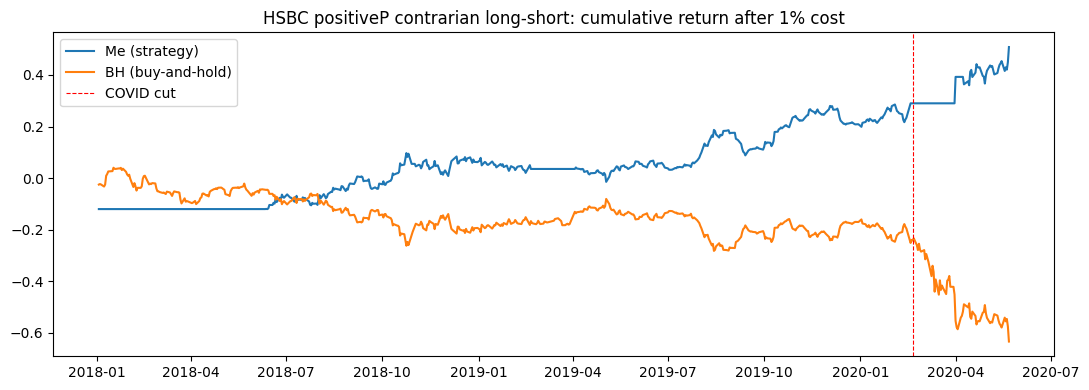

In [14]:
# Headline: HSBC positiveP, contrarian, long-short, RVT filter on (this is the tuned configuration).
hl_sig = zscore_band_signal(hsbc.positiveP, n=20, k=2.0, mode="contrarian", longshort=-1,
                            rvt=hsbc.RVT, rvt_q=0.85)
hl_res, hl_exc = test_strategy(hsbc.target, hl_sig)
print("Headline: HSBC positiveP contrarian long-short, n=20, k=2.0, RVT q=0.85")
print("Excess over buy-and-hold (Cumulative Return, Me - BH):", round(hl_exc, 3))
display(hl_res)

idx, cum_me, cum_bh = equity_curves(hsbc.target, hl_sig)
plt.figure(figsize=(11, 4))
plt.plot(idx, cum_me, label="Me (strategy)")
plt.plot(idx, cum_bh, label="BH (buy-and-hold)")
plt.axvline(COVID_CUT, color="red", lw=0.8, ls="--", label="COVID cut")
plt.title("HSBC positiveP contrarian long-short: cumulative return after 1% cost")
plt.legend()
plt.tight_layout()
plt.show()

The headline is not an isolated result. The next two rows in the matrix, HSBC `BULL` and HSBC `BBr` in the same contrarian long-short mode with the RVT filter, both clear buy-and-hold by close to 1.0 in cumulative excess, just behind the headline. The same rule applied to different sentiment indicators keeps beating buy-and-hold, which is the kind of agreement that argues against a single overfit point.

Two further results worth mentioning: the HSBC contrarian long-only rule (`positiveP`, `BBr`, `BULL`, or `negativeP` all give the same trade here) beats buy-and-hold with a single trade, which is the cleanest low-cost result in the matrix even though its absolute excess is smaller. On JPM the `PNlog` contrarian long-short rule is the standout. Both reinforce that the edge here is contrarian: fading sentiment extremes paid more than chasing them over this sample.

### 8.2 Pairs headline: relative-sentiment spread

This is the plan's flagship idea. We take the strongest pairs configuration that is positive on both the training and the held-out slice, rebuild its signal on the full sample, and show the Lab 6 metric table against the equal-weight benchmark together with the equity curve. The cell selects the configuration from the pairs table automatically, so the printed line tells you exactly which indicator, mode, and direction won.

The benchmark here is not single-stock buy-and-hold. It is the equal-weight long-both portfolio (half JPM, half HSBC), the passive alternative to running the spread. So the `Me minus BH` here answers a different question from the single-stock table: it asks whether actively trading the sentiment gap beat simply holding both banks.

Pairs headline: positiveP momentum long-short, n=20, k=2.0, rvt_q=None
Excess over equal-weight benchmark (Me - BH): 0.976  |  train 0.31  |  test 0.626  |  trades 12


,Me,BH
Cumulative Return,0.663051,-0.313062
Annual Return,0.237730,-0.145683
Annualized Sharpe Ratio,246.418958,-136.852516
Win %,0.520979,0.497504
Annualized Volatility,0.243115,0.268260
Maximum Drawdown,-0.806223,-0.263497
Max Length Drawdown,0.000000,0.000000
n.trades,12.000000,2.000000


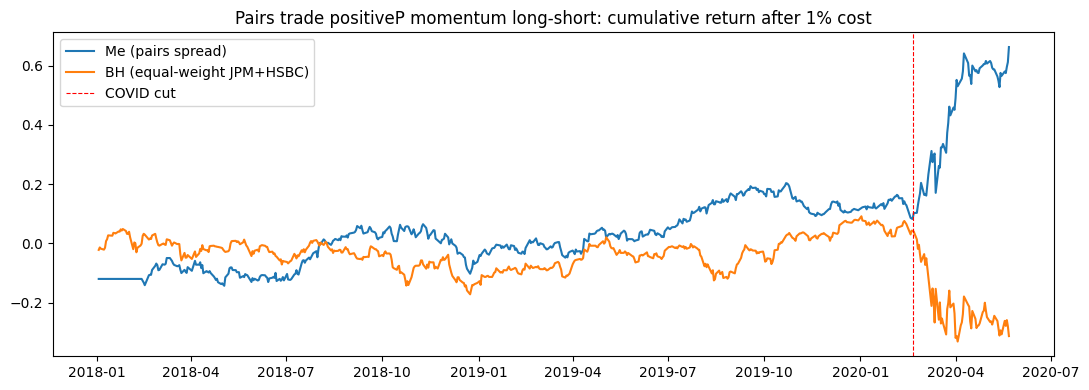

In [15]:
# Pairs headline: best pairs row that is positive on both the training and held-out slices.
pairs_cand = resB[(resB.train > 0) & (resB.test > 0)].sort_values("full", ascending=False)
if len(pairs_cand) == 0:
    pairs_cand = resB.sort_values("full", ascending=False)
ph = pairs_cand.iloc[0]
ph_ls = (ph["side"] == "long-short")
ph_rq = None if pd.isna(ph["rvt_q"]) else float(ph["rvt_q"])
ph_sig = pairs_zscore_signal(jpm[ph["ev"]], hsbc[ph["ev"]], n=int(ph["n"]), k=float(ph["k"]),
                             mode=ph["mode"], rvt_comb=rvt_comb, rvt_q=ph_rq)
ph_res, ph_exc = test_pairs(r_j, r_h, ph_sig, longshort=ph_ls)
print(f"Pairs headline: {ph['ev']} {ph['mode']} {ph['side']}, n={int(ph['n'])}, k={ph['k']}, rvt_q={ph_rq}")
print(f"Excess over equal-weight benchmark (Me - BH): {round(ph_exc, 3)}"
      f"  |  train {ph['train']}  |  test {ph['test']}  |  trades {int(ph['trades'])}")
display(ph_res)

idx, cum_me, cum_bh = pairs_equity_curves(r_j, r_h, ph_sig, longshort=ph_ls)
plt.figure(figsize=(11, 4))
plt.plot(idx, cum_me, label="Me (pairs spread)")
plt.plot(idx, cum_bh, label="BH (equal-weight JPM+HSBC)")
plt.axvline(COVID_CUT, color="red", lw=0.8, ls="--", label="COVID cut")
plt.title(f"Pairs trade {ph['ev']} {ph['mode']} {ph['side']}: cumulative return after 1% cost")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Cost inside the rolling windows

The rolling-window test slides a window of length 254 (about one trading year) and then 127 (about half a year) across the sample and averages the within-window mean daily return. The Lab 6 rolling routine does not charge a cost, here we charge it. We do this by spreading the lump trade cost for each window across the days in that window and subtracting it from the window's mean return. We show the result with the cost off (the lab behaviour) and with the cost on.

In [16]:
print("Rolling-window test on the single-stock headline (HSBC positiveP contrarian long-short)")
print("AvgPerf is the average across windows of the within-window mean daily return.")
for w in [254, 127]:
    roff, nw = rolling_test(hsbc.target, hl_sig, w_size=w, apply_cost=False)
    ron, _ = rolling_test(hsbc.target, hl_sig, w_size=w, apply_cost=True)
    print(f"window {w}: {nw} windows")
    print(f"  cost off : Me = {roff.loc['Me','AvgPerf']:+.5f}, BH = {roff.loc['BH','AvgPerf']:+.5f}")
    print(f"  cost on  : Me = {ron.loc['Me','AvgPerf']:+.5f}  (extra credit)")

Rolling-window test on the single-stock headline (HSBC positiveP contrarian long-short)
AvgPerf is the average across windows of the within-window mean daily return.
window 254: 347 windows
  cost off : Me = +0.00078, BH = -0.00047
  cost on  : Me = +0.00057  (extra credit)


window 127: 474 windows
  cost off : Me = +0.00088, BH = -0.00061
  cost on  : Me = +0.00063  (extra credit)


The single-stock headline holds up in the rolling test. With the cost off its average window return is above buy-and-hold, and with the cost on it stays positive and still beats buy-and-hold in both the 254 and 127 windows. The reason is turnover: at about a dozen trades over the whole sample, the cost spread across any single window is tiny, so charging it barely moves the average. This is the mirror image of the MAcross baseline, where the cost on roughly 80 trades would dominate. The per-window edge is small in absolute terms, which is the honest caveat, but it does not turn negative once cost is applied.

## 10. Analysis: COVID, parameter sensitivity, and cost

### 10.1 Pre-COVID versus COVID

We split the single-stock headline strategy's daily returns at 2020-02-20 and compare the cumulative result before and during the crash, for both the strategy and buy-and-hold. These sub-period figures are gross of the one-off trade cost, so they isolate the timing of the edge rather than its cost. This tells you how much of the edge is a crash effect.

In [17]:
bh_full = (hsbc.target / hsbc.target.shift(1) - 1)
me_full = (bh_full * hl_sig)
parts = []
for label, mask in [("pre-COVID", common < COVID_CUT), ("COVID", common >= COVID_CUT)]:
    m = me_full[mask].dropna()
    b = bh_full[mask].dropna()
    parts.append(dict(period=label, days=len(m),
                      Me_cum=round(m.sum(), 3), BH_cum=round(b.sum(), 3),
                      Me_minus_BH=round(m.sum() - b.sum(), 3)))
pd.DataFrame(parts)

,period,days,Me_cum,BH_cum,Me_minus_BH
0,pre-COVID,535,0.410,-0.220,0.630
1,COVID,66,0.218,-0.394,0.612


### 10.2 Parameter sensitivity

We hold the headline `ev`, mode, and direction fixed and sweep the window `n` against the threshold `k`, reporting the full-sample excess return on a grid. A strategy whose edge survives across neighbouring parameter values is more trustworthy than one that works at a single lucky point.

Full-sample excess (Me - BH) across n and k, HSBC positiveP contrarian long-short, RVT q=0.85
      k=0.5  k=1.0  k=1.5  k=2.0  k=2.5
n=10 -1.005 -0.025  0.618  0.631  0.868
n=20 -0.869 -0.082  0.356  1.142  1.025
n=40 -0.531 -0.073  0.409  0.841  0.976
n=60 -0.487 -0.037  0.379  1.025  0.976
n=80 -0.325 -0.067  0.156  1.025  0.976


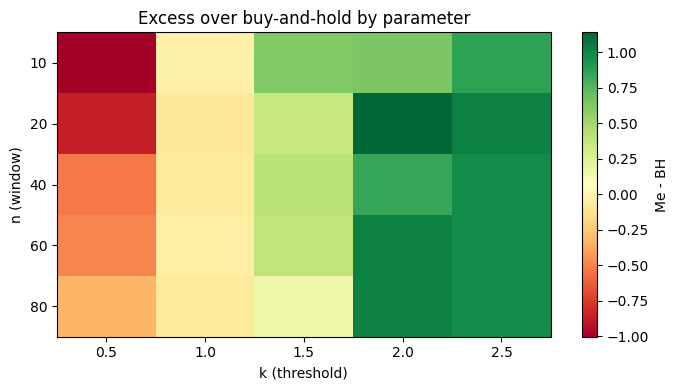

In [18]:
sens = pd.DataFrame(index=[f"n={n}" for n in NS], columns=[f"k={k}" for k in KS], dtype=float)
for n in NS:
    for k in KS:
        sig = zscore_band_signal(hsbc.positiveP, n=n, k=k, mode="contrarian", longshort=-1,
                                 rvt=hsbc.RVT, rvt_q=0.85)
        _, exc = test_strategy(hsbc.target, sig)
        sens.loc[f"n={n}", f"k={k}"] = round(exc, 3)
print("Full-sample excess (Me - BH) across n and k, HSBC positiveP contrarian long-short, RVT q=0.85")
print(sens)

plt.figure(figsize=(7, 4))
plt.imshow(sens.values.astype(float), aspect="auto", cmap="RdYlGn", origin="upper")
plt.xticks(range(len(KS)), [f"{k}" for k in KS])
plt.yticks(range(len(NS)), [f"{n}" for n in NS])
plt.xlabel("k (threshold)")
plt.ylabel("n (window)")
plt.title("Excess over buy-and-hold by parameter")
plt.colorbar(label="Me - BH")
plt.tight_layout()
plt.show()

The sensitivity grid is the most important robustness check in the notebook, and here it is reassuring. The excess is positive for every window length `n` once the threshold `k` is 1.5 or higher, and the whole right-hand side of the grid sits well above zero. The headline point at `n=20, k=2.0` is inside a broad positive plateau rather than on an isolated spike. The negative left side at `k=0.5` and `k=1.0` is expected: a low threshold trips the bands too often, so turnover and cost rise. The general rule to keep in mind for the rest of the project is to prefer a configuration that sits inside a stable positive region, which this one does.

## 11. Appendix: trade-by-trade log

In [19]:
def trade_segments(sig):
    # (first_active_date, last_active_date, position) for each run of constant non-zero position
    s = pd.Series(sig).dropna()
    vals = s.to_numpy()
    dates = s.index
    segs = []
    start = 0
    for i in range(1, len(vals) + 1):
        if i == len(vals) or vals[i] != vals[start]:
            if vals[start] != 0:
                segs.append((dates[start], dates[i - 1], float(vals[start])))
            start = i
    return segs

def entry_close_date(full_idx, first_active):
    # the close at which the position was entered: the day before it becomes active
    loc = full_idx.get_loc(first_active)
    return full_idx[loc - 1] if loc > 0 else first_active

def trade_log_single(price, sig):
    rows = []
    for d_act, d_exit, pos in trade_segments(sig):
        d_entry = entry_close_date(price.index, d_act)
        pe = float(price.loc[d_entry]); px = float(price.loc[d_exit])
        ret = pos * (px / pe - 1) * 100
        rows.append(dict(entry=d_entry.date(), exit=d_exit.date(),
                         days=int((d_exit - d_entry).days),
                         dir=("long" if pos > 0 else "short"),
                         entry_px=round(pe, 2), exit_px=round(px, 2),
                         ret_pct=round(ret, 2)))
    return pd.DataFrame(rows)

def trade_log_pairs(price_a, price_b, sig, name_a="JPM", name_b="HSBC"):
    rows = []
    for d_act, d_exit, pos in trade_segments(sig):
        d_entry = entry_close_date(price_a.index, d_act)
        ae = float(price_a.loc[d_entry]); axx = float(price_a.loc[d_exit])
        be = float(price_b.loc[d_entry]); bxx = float(price_b.loc[d_exit])
        spread = pos * ((axx / ae - 1) - (bxx / be - 1)) * 100
        posn = (name_a + " long / " + name_b + " short") if pos > 0 else (name_b + " long / " + name_a + " short")
        rows.append(dict(entry=d_entry.date(), exit=d_exit.date(), position=posn,
                         JPM_entry=round(ae, 2), JPM_exit=round(axx, 2),
                         HSBC_entry=round(be, 2), HSBC_exit=round(bxx, 2),
                         spread_pct=round(spread, 2)))
    return pd.DataFrame(rows)

log_single = trade_log_single(hsbc.target, hl_sig)
print("Single-stock headline: HSBC positiveP contrarian long-short, n=20, k=2.0, RVT q=0.85")
print(f"round-trip trades shown: {len(log_single)}  |  Lab 6 n.trades (position changes): {int(count_trades(hl_sig))}")
print(f"sum of per-trade price returns: {log_single.ret_pct.sum():+.2f}%  |  total cost at 1% per change: {count_trades(hl_sig) * COST * 100:.2f}%")
display(log_single)

log_pairs = trade_log_pairs(jpm.target, hsbc.target, ph_sig)
print(f"Pairs headline: {ph['ev']} {ph['mode']} {ph['side']}, n={int(ph['n'])}, k={ph['k']}")
print(f"round-trip trades shown: {len(log_pairs)}  |  Lab 6 n.trades (position changes, 2 legs): {int(count_trades(ph_sig) * 2)}")
print(f"sum of per-trade spread returns: {log_pairs.spread_pct.sum():+.2f}%  |  total cost at 1% per change: {count_trades(ph_sig) * 2 * COST * 100:.2f}%")
display(log_pairs)

Single-stock headline: HSBC positiveP contrarian long-short, n=20, k=2.0, RVT q=0.85
round-trip trades shown: 7  |  Lab 6 n.trades (position changes): 12
sum of per-trade price returns: +62.91%  |  total cost at 1% per change: 12.00%


,entry,exit,days,dir,entry_px,exit_px,ret_pct
0,2018-06-11,2018-10-29,140,short,43.83,36.55,16.61
1,2018-11-01,2019-02-20,111,short,37.81,38.33,-1.37
2,2019-04-03,2019-10-04,184,short,39.70,35.63,10.26
3,2019-10-04,2019-10-22,18,long,35.63,38.06,6.82
4,2019-10-22,2020-02-18,119,short,38.06,34.77,8.65
5,2020-03-31,2020-04-01,1,short,28.01,25.14,10.25
6,2020-04-08,2020-05-22,44,short,26.01,22.97,11.69


Pairs headline: positiveP momentum long-short, n=20, k=2.0
round-trip trades shown: 5  |  Lab 6 n.trades (position changes, 2 legs): 12
sum of per-trade spread returns: +69.95%  |  total cost at 1% per change: 12.00%


,entry,exit,position,JPM_entry,JPM_exit,HSBC_entry,HSBC_exit,spread_pct
0,2018-02-13,2019-10-24,JPM long / HSBC short,105.36,122.95,44.59,38.30,30.80
1,2019-10-24,2019-11-18,HSBC long / JPM short,122.95,128.45,38.30,36.14,-10.10
2,2019-11-18,2020-02-11,JPM long / HSBC short,128.45,136.58,36.14,37.12,3.62
3,2020-02-11,2020-03-20,HSBC long / JPM short,136.58,82.64,37.12,28.81,17.10
4,2020-03-20,2020-05-22,JPM long / HSBC short,82.64,89.47,28.81,22.97,28.53
